<a href="https://colab.research.google.com/github/Arther-Codes/Deep-learning-Based-Detection-Of-Alzheimer-s-Disease/blob/main/AD_Hybrid_CNN_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
# 1. Ensure gdown is ready
!pip install -q gdown

# 2. Download the Dataset
!gdown --id '1YAAUR4U1yWXoWWnIUeRyRBy4Ctfuaef7' -O dataset.zip

# 3. Download the Manual Inference Samples
!gdown --id '1i5xg-Cwx8PM92D2i9C4VbhurkkbUANmh' -O inference_samples.zip

print("✅ All project assets downloaded!!")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1YAAUR4U1yWXoWWnIUeRyRBy4Ctfuaef7
From (redirected): https://drive.google.com/uc?id=1YAAUR4U1yWXoWWnIUeRyRBy4Ctfuaef7&confirm=t&uuid=82b67d6d-818c-4cef-a4a6-6f991944c4f8
To: /content/dataset.zip
100% 54.1M/54.1M [00:00<00:00, 77.8MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1i5xg-Cwx8PM92D2i9C4VbhurkkbUANmh
To: /content/inference_samples.zip
100% 236k/236k [00:00<00:00, 93.9MB/s]
✅ All project assets downloaded!!


In [49]:
# unzip so the files are ready for the model
!unzip -q dataset.zip -d ./data
!unzip -q inference_samples.zip -d ./test_images

In [50]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications.inception_v3 import preprocess_input

In [51]:
# Hyperparameters
img_height, img_width = 299, 299  # InceptionV3 preferred input size
batch_size = 32
learning_rate = 1e-4
epochs = 30
validation_split = 0.2

In [52]:
train_dir = r"/content/data/Kaggle/Combined Dataset/train"
test_dir = r"/content/data/Kaggle/Combined Dataset/test"

In [53]:
# Data preprocessing
def data_preprocessing(output_size, val_split=0.1):
    train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                       zoom_range=0.2,
                                       shear_range=0.2,
                                       rotation_range=15,
                                       fill_mode='nearest',
                                       horizontal_flip=True,
                                       validation_split=val_split)

    training_set = train_datagen.flow_from_directory(train_dir,
                                                     target_size=(output_size, output_size),
                                                     batch_size=batch_size,
                                                     class_mode='categorical',
                                                     shuffle=True,
                                                     subset='training')

    validation_set = train_datagen.flow_from_directory(train_dir,
                                                       target_size=(output_size, output_size),
                                                       batch_size=batch_size,
                                                       class_mode='categorical',
                                                       shuffle=True,
                                                       subset='validation')
    return training_set, validation_set


In [54]:
def test_data_preprocessing(output_size):
    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
    return test_datagen.flow_from_directory(test_dir,
                                            target_size=(output_size, output_size),
                                            batch_size=batch_size,
                                            class_mode='categorical',
                                            shuffle=False)

In [55]:
def compute_class_weights(train_generator):
    class_weights = compute_class_weight('balanced', classes=np.unique(train_generator.classes), y=train_generator.classes)
    return {i: weight for i, weight in enumerate(class_weights)}


In [56]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_custom_cnn_model():
    model = Sequential([
        Input(shape=(128, 128, 3)),  # <-- This is the key fix
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(3, activation='softmax')  # assuming 3 classes
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [57]:
# Evaluate model
def evaluate_model(model, test_generator):
    predictions = model.predict(test_generator)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = test_generator.classes
    class_labels = list(test_generator.class_indices.keys())
    print("\nClassification Report:")
    print(classification_report(true_classes, predicted_classes, target_names=class_labels, digits=2))



In [58]:
# Function to plot training history
def plot_training_history(history, title="Training History"):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()


Found 6690 images belonging to 3 classes.
Found 743 images belonging to 3 classes.
Found 788 images belonging to 3 classes.

Starting training...
Epoch 1/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 127s 595ms/step - accuracy: 0.5634 - loss: 0.9724 - val_accuracy: 0.7672 - val_loss: 0.6081 - learning_rate: 0.0010
Epoch 2/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 122s 579ms/step - accuracy: 0.7729 - loss: 0.5274 - val_accuracy: 0.8062 - val_loss: 0.4869 - learning_rate: 0.0010
Epoch 3/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 123s 585ms/step - accuracy: 0.8212 - loss: 0.4140 - val_accuracy: 0.8398 - val_loss: 0.3566 - learning_rate: 0.0010
Epoch 4/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 120s 572ms/step - accuracy: 0.8451 - loss: 0.3453 - val_accuracy: 0.8694 - val_loss: 0.3035 - learning_rate: 0.0010
Epoch 5/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 120s 572ms/step - accuracy: 0.8610 - loss: 0.3162 - val_accuracy: 0.8896 - val_loss: 0.2636 - learning_rate: 0.0010
Epoch 6/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 142s 572ms/step - accuracy: 0.8628

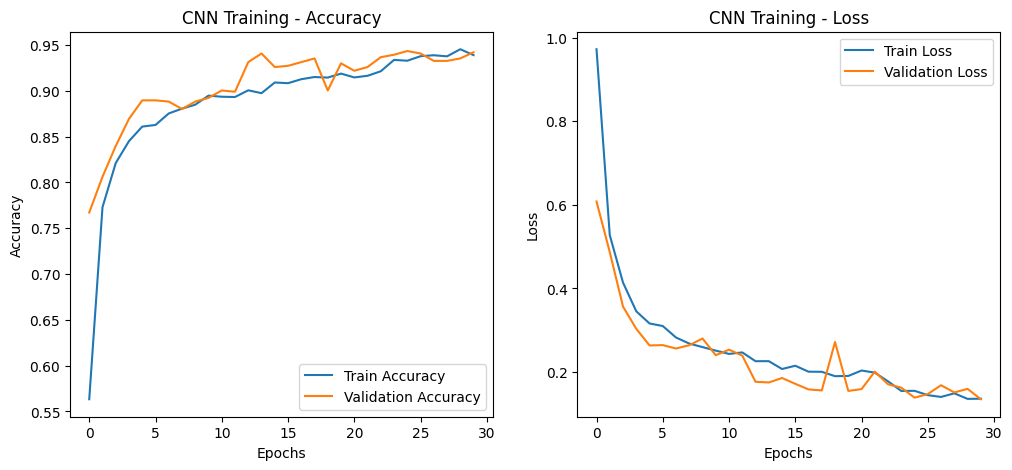

Model saved as 'alzheimers_cnn_model.h5'
Model loaded successfully!
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step

Classification Report:
                     precision    recall  f1-score   support

    Mild Impairment       0.96      0.82      0.89       264
Moderate Impairment       1.00      0.98      0.99       264
      No Impairment       0.84      0.98      0.90       260

           accuracy                           0.93       788
          macro avg       0.93      0.93      0.93       788
       weighted avg       0.93      0.93      0.93       788



In [59]:
# Main function
def main():
    train_generator, val_generator = data_preprocessing(output_size=128, val_split=0.1)
    test_generator = test_data_preprocessing(output_size=128)
    class_weights = compute_class_weights(train_generator)
    model = build_custom_cnn_model()  # This should include Input(shape=(128, 128, 3)) as first layer

    callbacks = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
    ]

    epochs = 30

    print("\nStarting training...")
    history = model.fit(
        train_generator,
        epochs=epochs,
        validation_data=val_generator,
        callbacks=callbacks,
        class_weight=class_weights
    )

    plot_training_history(history, title="CNN Training")
    model.save('alzheimers_cnn_model.h5')
    print("Model saved as 'alzheimers_cnn_model.h5'")

    loaded_model = load_model('alzheimers_cnn_model.h5')
    print("Model loaded successfully!")
    evaluate_model(loaded_model, test_generator)

if __name__ == "__main__":
    main()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [ ]:
model_path = '/content/alzheimers_cnn_model.h5'
model = load_model(model_path)
print(f"✅ Model '{model_path}' loaded successfully.")

✅ Model '/content/alzheimers_cnn_model.h5' loaded successfully.


In [ ]:
def predict_local_scan(img_path):

    class_names = ['Mild Impairment', 'Moderate Impairment', 'No Impairment']

    # Here we are matching the input image we give to the dimensions of the models input
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    # Prediction
    predictions = model.predict(img_array)
    score = predictions[0]
    predicted_class = class_names[np.argmax(score)]
    confidence = 100 * np.max(score)

    #Visualization
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Class: {predicted_class}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

In [41]:
#Now we should unzip the "Test The Model" folder to test the model which was saved

In [44]:
 #Create a destination folder for the Testing dataset
!mkdir -p /content/Testing_dataset

# Unzip the file from Drive to the local Colab environment
# Use quotes if your file path has spaces
!unzip -q "/content/drive/MyDrive/Dataset_CNN_Project/Test The Model.zip" -d /content/Testing_dataset

In [46]:
#In order to test with an image select the path of the image from the Testing_dataset folder we created and past below

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


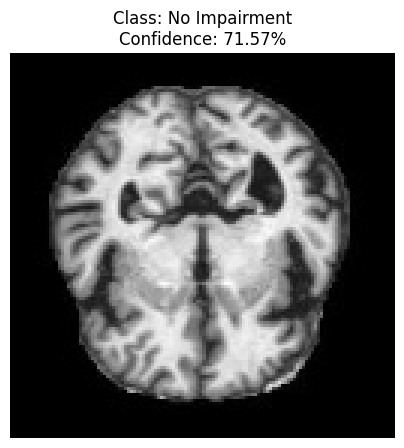

In [45]:
test_image = '/content/Testing_dataset/Test The Model/MildImpairment (1).jpg'
predict_local_scan(test_image)